In [6]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display
import constantes as const

tf.random.set_seed(const.RANDOM_SEED)
np.random.seed(const.RANDOM_SEED)

In [21]:
import zipfile
import pathlib
import tensorflow as tf

DATASET_PATH = 'data/train_curated.zip'

extracted_dir = pathlib.Path('data/train_curated')
if not extracted_dir.exists():
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall('data/train_curated')

data_dir = pathlib.Path('data/train_curated')

audio_files = list(data_dir.glob('**/*.wav'))

audio_file_paths = [str(path) for path in audio_files]

def load_audio(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary)
    return audio

audio_dataset = tf.data.Dataset.from_tensor_slices(audio_file_paths)

audio_dataset = audio_dataset.map(lambda x: load_audio(x))

for audio in audio_dataset.take(5):
    print(audio.shape)


(310456, 1)
(90616, 1)
(66976, 1)
(1125886, 1)
(60638, 1)


In [31]:
import tensorflow as tf
import pathlib
import zipfile

DATASET_PATH = 'data/train_curated.zip'

extracted_dir = pathlib.Path('data/train_curated')
if not extracted_dir.exists():
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall('data/train_curated')

data_dir = pathlib.Path('data/train_curated')

filenames = [str(path) for path in data_dir.glob('*.wav')]

filenames = tf.random.shuffle(filenames)
print('Shuffled filenames:', filenames)

num_samples = len(filenames)
print('Number of total examples:', num_samples)

if num_samples > 0:
    print('Example file tensor:', filenames[0])
else:
    print('No files found in the dataset.')

def load_audio(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary)
    return audio

audio_dataset = tf.data.Dataset.from_tensor_slices(filenames)

audio_dataset = audio_dataset.map(lambda x: load_audio(x))

for audio in audio_dataset.take(5):
    print(audio.shape)


Shuffled filenames: tf.Tensor(
[b'data\\train_curated\\95b1fcd5.wav' b'data\\train_curated\\64f20075.wav'
 b'data\\train_curated\\10138a66.wav' ...
 b'data\\train_curated\\e64dc8f3.wav' b'data\\train_curated\\e042a81d.wav'
 b'data\\train_curated\\f77a898b.wav'], shape=(4970,), dtype=string)
Number of total examples: 4970
Example file tensor: tf.Tensor(b'data\\train_curated\\95b1fcd5.wav', shape=(), dtype=string)
(121400, 1)
(1238580, 1)
(372728, 1)
(546816, 1)
(1243698, 1)


In [38]:
print(len(filenames))
train_files = filenames[:3000]
val_files = filenames[3000:]

print('Training set size', len(train_files))
print('Validation set size', len(val_files))

4970
Training set size 3000
Validation set size 1970


In [44]:
test_file = tf.io.read_file('C:/Users/Valen/Desktop/Laboratorio-2-TAA/data/train_curated/0a9bebde.wav')
test_audio, _ = tf.audio.decode_wav(contents=test_file)
test_audio.shape

TensorShape([75601, 1])

In [45]:
def decode_audio(audio_binary):
  # Decode WAV-encoded audio files to `float32` tensors, normalized
  # to the [-1.0, 1.0] range. Return `float32` audio and a sample rate.
  audio, _ = tf.audio.decode_wav(contents=audio_binary)
  # Since all the data is single channel (mono), drop the `channels`
  # axis from the array.
  return tf.squeeze(audio, axis=-1)

In [46]:
def get_label(file_path):
  parts = tf.strings.split(
      input=file_path,
      sep=os.path.sep)
  # Note: You'll use indexing here instead of tuple unpacking to enable this
  # to work in a TensorFlow graph.
  return parts[-2]

In [47]:
def get_waveform_and_label(file_path):
  label = get_label(file_path)
  audio_binary = tf.io.read_file(file_path)
  waveform = decode_audio(audio_binary)
  return waveform, label

In [48]:
AUTOTUNE = tf.data.AUTOTUNE

files_ds = tf.data.Dataset.from_tensor_slices(train_files)

waveform_ds = files_ds.map(
    map_func=get_waveform_and_label,
    num_parallel_calls=AUTOTUNE)

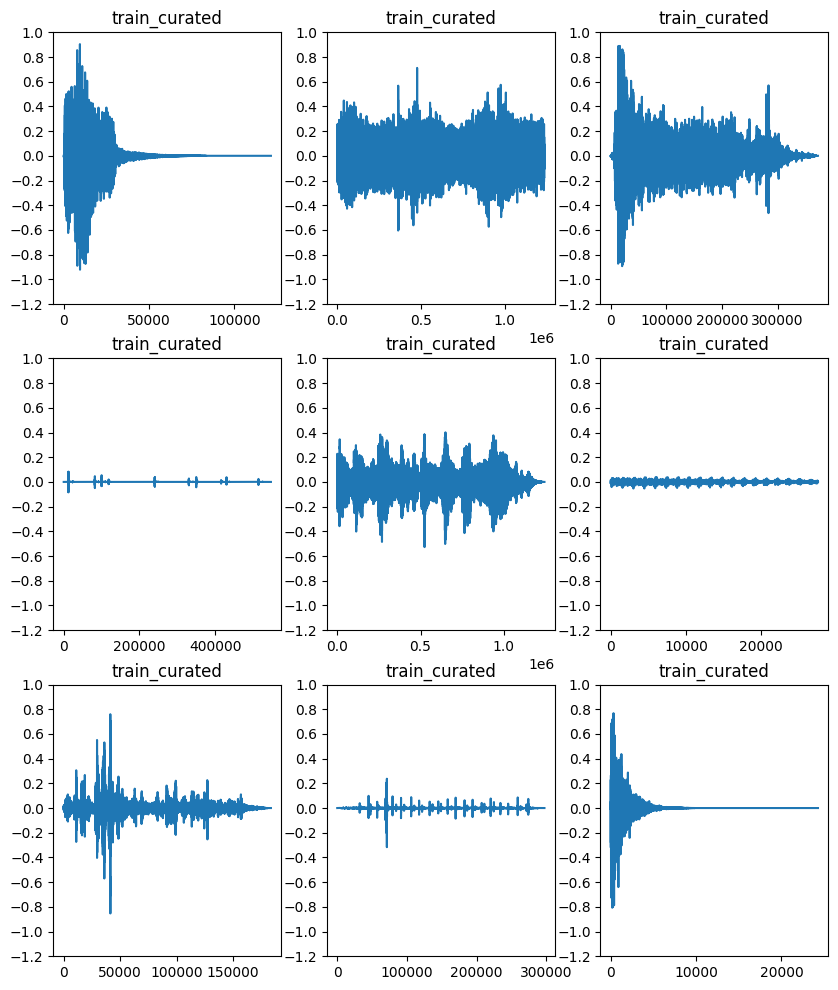

In [49]:
rows = 3
cols = 3
n = rows * cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 12))

for i, (audio, label) in enumerate(waveform_ds.take(n)):
  r = i // cols
  c = i % cols
  ax = axes[r][c]
  ax.plot(audio.numpy())
  ax.set_yticks(np.arange(-1.2, 1.2, 0.2))
  label = label.numpy().decode('utf-8')
  ax.set_title(label)

plt.show()

In [50]:
def get_spectrogram(waveform):
  # Zero-padding for an audio waveform with less than 16,000 samples.
  input_len = 16000
  waveform = waveform[:input_len]
  zero_padding = tf.zeros(
      [16000] - tf.shape(waveform),
      dtype=tf.float32)
  # Cast the waveform tensors' dtype to float32.
  waveform = tf.cast(waveform, dtype=tf.float32)
  # Concatenate the waveform with `zero_padding`, which ensures all audio
  # clips are of the same length.
  equal_length = tf.concat([waveform, zero_padding], 0)
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      equal_length, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

In [51]:
for waveform, label in waveform_ds.take(1):
  label = label.numpy().decode('utf-8')
  spectrogram = get_spectrogram(waveform)

print('Label:', label)
print('Waveform shape:', waveform.shape)
print('Spectrogram shape:', spectrogram.shape)
print('Audio playback')
display.display(display.Audio(waveform, rate=16000))

Label: train_curated
Waveform shape: (121400,)
Spectrogram shape: (124, 129, 1)
Audio playback


In [52]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

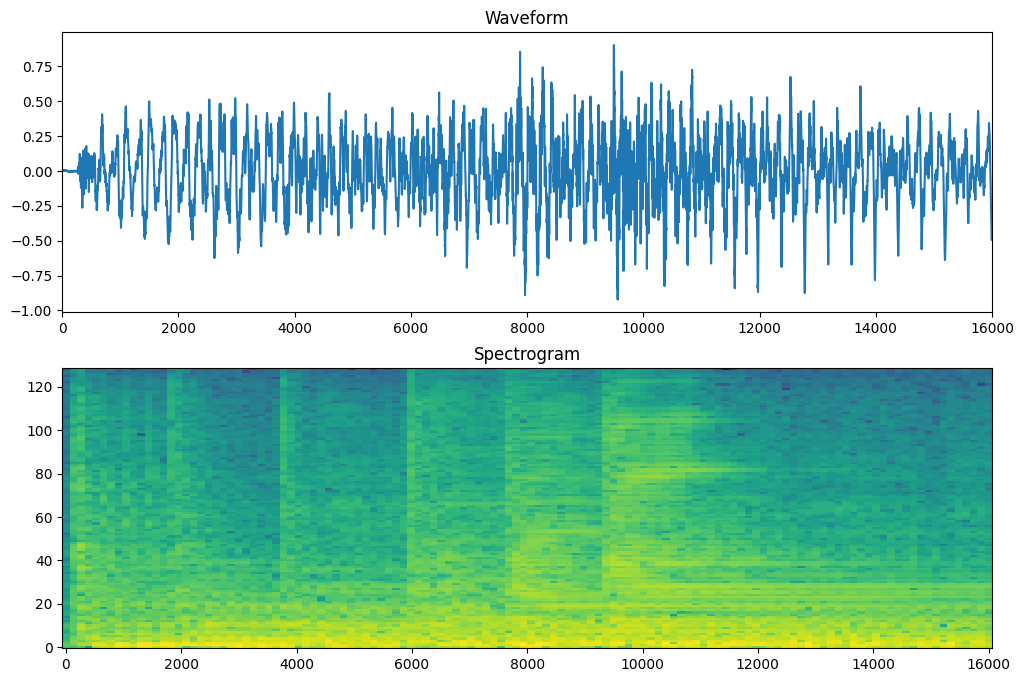

In [53]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.show()

In [55]:
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[commands != 'README.md']
print('Commands:', commands)

Commands: ['0006ae4e.wav' '0019ef41.wav' '001ec0ad.wav' ... 'ffe2178b.wav'
 'fffa69b7.wav' 'ffff4631.wav']


In [56]:
def get_spectrogram_and_label_id(audio, label):
  spectrogram = get_spectrogram(audio)
  label_id = tf.argmax(label == commands)
  return spectrogram, label_id

In [57]:
spectrogram_ds = waveform_ds.map(
  map_func=get_spectrogram_and_label_id,
  num_parallel_calls=AUTOTUNE)

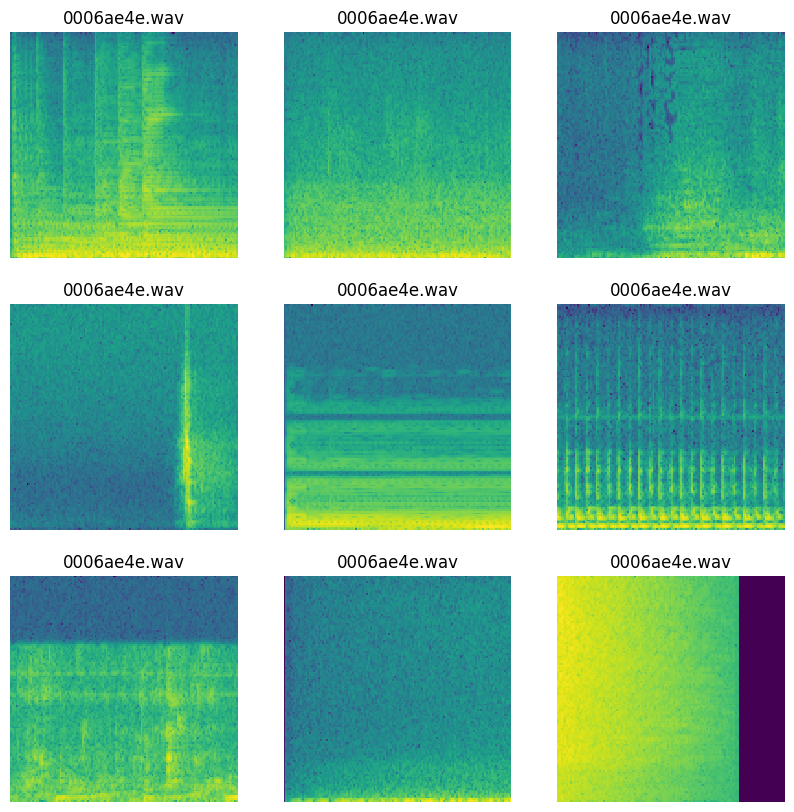

In [58]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

for i, (spectrogram, label_id) in enumerate(spectrogram_ds.take(n)):
  r = i // cols
  c = i % cols
  ax = axes[r][c]
  plot_spectrogram(spectrogram.numpy(), ax)
  ax.set_title(commands[label_id.numpy()])
  ax.axis('off')

plt.show()

In [59]:
def preprocess_dataset(files):
  files_ds = tf.data.Dataset.from_tensor_slices(files)
  output_ds = files_ds.map(
      map_func=get_waveform_and_label,
      num_parallel_calls=AUTOTUNE)
  output_ds = output_ds.map(
      map_func=get_spectrogram_and_label_id,
      num_parallel_calls=AUTOTUNE)
  return output_ds

In [61]:
train_ds = spectrogram_ds
val_ds = preprocess_dataset(val_files)

In [62]:
batch_size = 64
train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)

In [63]:
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [73]:
import pandas as pd 

df = pd.read_csv('C:/Users/Valen/Desktop/Laboratorio-2-TAA/train_curated.csv')
df.head()

,fname,labels
0,0006ae4e.wav,Bark
1,0019ef41.wav,Raindrop
2,001ec0ad.wav,Finger_snapping
3,0026c7cb.wav,Run
4,0026f116.wav,Finger_snapping


In [76]:
import tensorflow as tf
import pathlib
import pandas as pd

# Define the dataset path
DATASET_PATH = 'data/train_curated.zip'

# Extract the zip file (if not already extracted)
extracted_dir = pathlib.Path('data/train_curated')
if not extracted_dir.exists():
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall('data/train_curated')

# Load the CSV file
df = pd.read_csv('C:/Users/Valen/Desktop/Laboratorio-2-TAA/train_curated.csv')

# Create a mapping from filenames to labels
file_label_mapping = dict(zip(df['fname'], df['labels']))

# Get the unique labels and create a label to index mapping
unique_labels = sorted(set(df['labels']))
label_to_index = {label: index for index, label in enumerate(unique_labels)}
num_labels = len(unique_labels)

print("Unique labels:", unique_labels)
print("Number of labels:", num_labels)


Unique labels: ['Accelerating_and_revving_and_vroom', 'Accordion', 'Acoustic_guitar', 'Acoustic_guitar,Strum', 'Applause,Cheering', 'Applause,Cheering,Clapping', 'Applause,Clapping', 'Applause,Crowd', 'Applause,Crowd,Cheering', 'Applause,Crowd,Clapping', 'Applause,Dishes_and_pots_and_pans,Crowd,Cheering,Clapping,Child_speech_and_kid_speaking', 'Applause,Harmonica', 'Applause,Harmonica,Cheering', 'Applause,Screaming,Crowd', 'Bark', 'Bark,Chirp_and_tweet', 'Bark,Cricket', 'Bark,Cricket,Buzz', 'Bark,Walk_and_footsteps', 'Bass_drum', 'Bass_guitar', 'Bathtub_(filling_or_washing)', 'Bathtub_(filling_or_washing),Child_speech_and_kid_speaking', 'Bathtub_(filling_or_washing),Gurgling', 'Bathtub_(filling_or_washing),Sink_(filling_or_washing)', 'Bathtub_(filling_or_washing),Sink_(filling_or_washing),Water_tap_and_faucet', 'Bathtub_(filling_or_washing),Water_tap_and_faucet', 'Bicycle_bell', 'Burping_and_eructation', 'Burping_and_eructation,Chewing_and_mastication', 'Bus', 'Buzz', 'Car_passing_by',

In [80]:
import tensorflow as tf
import pathlib
import pandas as pd
import numpy as np
import zipfile

# Define the dataset path
DATASET_PATH = 'data/train_curated.zip'

# Extract the zip file (if not already extracted)
extracted_dir = pathlib.Path('data/train_curated')
if not extracted_dir.exists():
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall('data/train_curated')

# Load the CSV file
df = pd.read_csv('C:/Users/Valen/Desktop/Laboratorio-2-TAA/train_curated.csv')

# Create a mapping from filenames to labels
file_label_mapping = dict(zip(df['fname'], df['labels']))

# Get the unique labels and create a label to index mapping
unique_labels = sorted(set(df['labels']))
label_to_index = {label: index for index, label in enumerate(unique_labels)}
num_labels = len(unique_labels)

print("Unique labels:", unique_labels)
print("Number of labels:", num_labels)

# Function to load and preprocess audio files
def load_audio_and_label(file_path):
    file_path_str = file_path.numpy().decode('utf-8')
    file_name = pathlib.Path(file_path_str).name
    label = file_label_mapping[file_name]
    label_index = label_to_index[label]

    audio_binary = tf.io.read_file(file_path_str)
    audio, _ = tf.audio.decode_wav(audio_binary)
    
    # Pad or truncate audio to fixed length (e.g., 16000 samples)
    fixed_length = 16000
    audio = tf.pad(audio, [[0, fixed_length - tf.shape(audio)[0]], [0, 0]], mode='CONSTANT')
    audio = tf.slice(audio, [0, 0], [fixed_length, -1])
    
    return audio, label_index

# List all audio file paths and convert them to strings
data_dir = pathlib.Path('data/train_curated')
filenames = [str(path) for path in data_dir.glob('*.wav')]

# Create a TensorFlow dataset from the list of file paths
audio_paths_ds = tf.data.Dataset.from_tensor_slices(filenames)

# Map the load_audio_and_label function to each file path
audio_label_ds = audio_paths_ds.map(
    lambda x: tf.py_function(func=load_audio_and_label, inp=[x], Tout=(tf.float32, tf.int32))
)

# Batch and prefetch the dataset
batch_size = 32
train_ds = audio_label_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

Unique labels: ['Accelerating_and_revving_and_vroom', 'Accordion', 'Acoustic_guitar', 'Acoustic_guitar,Strum', 'Applause,Cheering', 'Applause,Cheering,Clapping', 'Applause,Clapping', 'Applause,Crowd', 'Applause,Crowd,Cheering', 'Applause,Crowd,Clapping', 'Applause,Dishes_and_pots_and_pans,Crowd,Cheering,Clapping,Child_speech_and_kid_speaking', 'Applause,Harmonica', 'Applause,Harmonica,Cheering', 'Applause,Screaming,Crowd', 'Bark', 'Bark,Chirp_and_tweet', 'Bark,Cricket', 'Bark,Cricket,Buzz', 'Bark,Walk_and_footsteps', 'Bass_drum', 'Bass_guitar', 'Bathtub_(filling_or_washing)', 'Bathtub_(filling_or_washing),Child_speech_and_kid_speaking', 'Bathtub_(filling_or_washing),Gurgling', 'Bathtub_(filling_or_washing),Sink_(filling_or_washing)', 'Bathtub_(filling_or_washing),Sink_(filling_or_washing),Water_tap_and_faucet', 'Bathtub_(filling_or_washing),Water_tap_and_faucet', 'Bicycle_bell', 'Burping_and_eructation', 'Burping_and_eructation,Chewing_and_mastication', 'Bus', 'Buzz', 'Car_passing_by',

In [ ]:
# Model definition and training
from tensorflow.keras import layers, models

# Get the input shape from the dataset
for audio, _ in train_ds.take(1):
    input_shape = audio.shape[1:]
print('Input shape:', input_shape)

# Instantiate the `tf.keras.layers.Normalization` layer
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
norm_layer.adapt(train_ds.map(map_func=lambda spec, label: spec))

# Define the model
model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

# Split the dataset into training and validation sets
val_size = int(0.2 * len(filenames))
val_ds = audio_label_ds.take(val_size).batch(batch_size).prefetch(tf.data.AUTOTUNE)
train_ds = audio_label_ds.skip(val_size).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Train the model
EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[tf.keras.callbacks.EarlyStopping(verbose=1, patience=2)],
)

In [86]:
import tensorflow as tf
import pathlib
import pandas as pd
import numpy as np
import zipfile

# Define the dataset path
DATASET_PATH = 'data/train_curated.zip'

# Extract the zip file (if not already extracted)
extracted_dir = pathlib.Path('data/train_curated')
if not extracted_dir.exists():
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall('data/train_curated')

# Load the CSV file
df = pd.read_csv('C:/Users/Valen/Desktop/Laboratorio-2-TAA/train_curated.csv')

# Create a mapping from filenames to labels
file_label_mapping = dict(zip(df['fname'], df['labels']))

# Get the unique labels and create a label to index mapping
unique_labels = sorted(set(df['labels']))
label_to_index = {label: index for index, label in enumerate(unique_labels)}
num_labels = len(unique_labels)

print("Unique labels:", unique_labels)
print("Number of labels:", num_labels)


Unique labels: ['Accelerating_and_revving_and_vroom', 'Accordion', 'Acoustic_guitar', 'Acoustic_guitar,Strum', 'Applause,Cheering', 'Applause,Cheering,Clapping', 'Applause,Clapping', 'Applause,Crowd', 'Applause,Crowd,Cheering', 'Applause,Crowd,Clapping', 'Applause,Dishes_and_pots_and_pans,Crowd,Cheering,Clapping,Child_speech_and_kid_speaking', 'Applause,Harmonica', 'Applause,Harmonica,Cheering', 'Applause,Screaming,Crowd', 'Bark', 'Bark,Chirp_and_tweet', 'Bark,Cricket', 'Bark,Cricket,Buzz', 'Bark,Walk_and_footsteps', 'Bass_drum', 'Bass_guitar', 'Bathtub_(filling_or_washing)', 'Bathtub_(filling_or_washing),Child_speech_and_kid_speaking', 'Bathtub_(filling_or_washing),Gurgling', 'Bathtub_(filling_or_washing),Sink_(filling_or_washing)', 'Bathtub_(filling_or_washing),Sink_(filling_or_washing),Water_tap_and_faucet', 'Bathtub_(filling_or_washing),Water_tap_and_faucet', 'Bicycle_bell', 'Burping_and_eructation', 'Burping_and_eructation,Chewing_and_mastication', 'Bus', 'Buzz', 'Car_passing_by',

In [87]:
# Function to load and preprocess audio files
def load_audio_and_label(file_path):
    file_path_str = file_path.numpy().decode('utf-8')
    file_name = pathlib.Path(file_path_str).name
    label = file_label_mapping[file_name]
    label_index = label_to_index[label]

    audio_binary = tf.io.read_file(file_path_str)
    audio, _ = tf.audio.decode_wav(audio_binary)
    
    # Pad or truncate audio to fixed length (e.g., 16000 samples)
    fixed_length = 16000
    audio_length = tf.shape(audio)[0]
    if audio_length < fixed_length:
        padding = fixed_length - audio_length
        audio = tf.pad(audio, [[0, padding], [0, 0]], mode='CONSTANT')
    else:
        audio = tf.slice(audio, [0, 0], [fixed_length, -1])
    
    # Add the channel dimension
    audio = tf.expand_dims(audio, axis=-1)
    
    return audio, label_index

# List all audio file paths and convert them to strings
data_dir = pathlib.Path('data/train_curated')
filenames = [str(path) for path in data_dir.glob('*.wav')]

# Create a TensorFlow dataset from the list of file paths
audio_paths_ds = tf.data.Dataset.from_tensor_slices(filenames)

# Map the load_audio_and_label function to each file path
audio_label_ds = audio_paths_ds.map(
    lambda x: tf.py_function(func=load_audio_and_label, inp=[x], Tout=(tf.float32, tf.int32)),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Explicitly set the shapes for the dataset
def set_shapes(audio, label):
    audio.set_shape([16000, 1, 1])  # Fixed length and single channel
    label.set_shape([])
    return audio, label

audio_label_ds = audio_label_ds.map(set_shapes, num_parallel_calls=tf.data.AUTOTUNE)

# Batch and prefetch the dataset
batch_size = 32
train_ds = audio_label_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [88]:
from tensorflow.keras import layers, models

# Get the input shape from the dataset
for audio, _ in train_ds.take(1):
    input_shape = audio.shape[1:]
print('Input shape:', input_shape)

# Instantiate the `tf.keras.layers.Normalization` layer
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
norm_layer.adapt(train_ds.map(map_func=lambda spec, label: spec))

# Define the model
model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(32, 32),
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)


Input shape: (16000, 1, 1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_4 (Normalization) │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 213)            │        27,477 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,652,056 (6.30 MB)

 Trainable params: 1,652,053 (6.30 MB)

 Non-trainable params: 3 (16.00 B)

In [91]:

# Split the dataset into training and validation sets
val_size = int(0.2 * len(filenames))
val_ds = audio_label_ds.take(val_size).batch(batch_size).prefetch(tf.data.AUTOTUNE)
train_ds = audio_label_ds.skip(val_size).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Train the model
EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[tf.keras.callbacks.EarlyStopping(verbose=1, patience=5)],
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.0694 - loss: 4.2255 - val_accuracy: 0.0684 - val_loss: 4.3972
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.0697 - loss: 4.1734 - val_accuracy: 0.0604 - val_loss: 4.4283
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.0836 - loss: 4.1397 - val_accuracy: 0.0573 - val_loss: 4.4128
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.1051 - loss: 4.0365 - val_accuracy: 0.0714 - val_loss: 4.4245
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.0959 - loss: 4.0297 - val_accuracy: 0.0795 - val_loss: 4.4345
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.1051 - loss: 3.9586 - val_accuracy: 0.0654 - val_loss: 4.4872
Epoch 6: early stopping


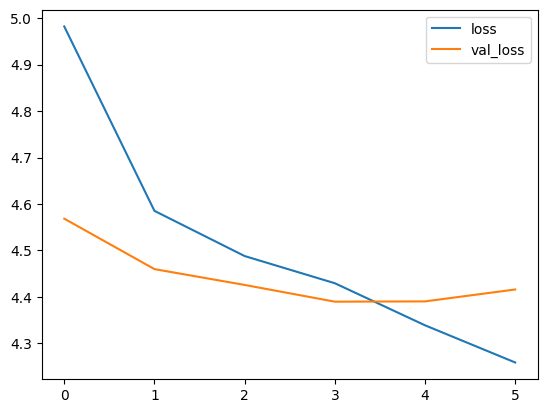

In [90]:
metrics = history.history
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (31,) + inhomogeneous part.

In [69]:
y_pred = np.argmax(model.predict(test_audio), axis=1)
y_true = 

test_acc = sum(y_pred == y_true) / len(y_true)
print(f'Test set accuracy: {test_acc:.0%}')

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test set accuracy: 100%
